# The lean of a throw

Notebook 12 gave the throw a shape and notebook 13 gave it a pull, but both left the ellipse
**axis-aligned** -- stretched vertically or horizontally and never leaning. The code has
supported a tilt throughout (`sigma_matrices` takes a correlation, the particle filter
carries `atanh rho`), and no experiment has ever used it. This is that experiment.

Tilt is the natural third parameter of a throw. An arm swings on an arc from a shoulder that
is not directly behind the dart, so there is no particular reason for a player's error
ellipse to line up with the board's vertical.

The same three questions as notebook 12:

1. **Does the lean change the board?** Does a group leaning 30 degrees face a different game
   from the same group upright?
2. **Can the lean be learned from scores?**
3. **What does ignoring it cost?**

I went in expecting the second answer to be the disappointing one -- a correlation felt like
a subtler thing to read out of a score histogram than a spread. That turned out to be
exactly backwards, which is the most useful thing in this notebook.

## The third parameter, and why the board is not indifferent to it

**Where the tilt lives.** A $2\times2$ covariance has three free numbers, and
notebook 12 used two of them. The third is the off-diagonal:

$$\Sigma = \begin{pmatrix} \sigma_x^2 & \rho\,\sigma_x\sigma_y \\ \rho\,\sigma_x\sigma_y & \sigma_y^2 \end{pmatrix}, \qquad \rho \in (-1, 1)$$

Notebook 12 set $\rho = 0$; this notebook lets it go. With three parameters the
model is a *completely general* Gaussian throw — there is no fourth thing an
ellipse can do.

**Two descriptions of the same matrix, and the second is the useful one.** Any
$\Sigma$ can be written as an ellipse rotated off the board's axes,

$$\Sigma = R(\phi)\begin{pmatrix} \sigma_{\text{major}}^2 & 0 \\ 0 & \sigma_{\text{minor}}^2\end{pmatrix} R(\phi)^{\!\top}, \qquad R(\phi) = \begin{pmatrix}\cos\phi & -\sin\phi \\ \sin\phi & \cos\phi\end{pmatrix}$$

which is the eigendecomposition, with $\phi$ the angle of the major axis from the
horizontal. "A 20 by 12 group leaning 30 degrees" is a description a player could
recognise; $\rho = 0.42$ is not. The two are related by

$$\tan 2\phi \;=\; \frac{2\rho\,\sigma_x\sigma_y}{\sigma_x^2 - \sigma_y^2}$$

and the factor of 2 is not decoration: an ellipse leaning $30^\circ$ and one
leaning $210^\circ$ are the same ellipse, so $\phi$ is only defined modulo
$180^\circ$ and it is $2\phi$ that goes round once. That periodicity is a real
nuisance for any estimator, and notebook 25 eventually pays for it.

**Why $\rho$ is not "the lean".** Rotating an ellipse changes $\rho$ *and* both
marginal spreads together, so $\rho$ confounds two things. Writing the
off-diagonal in the ellipse's own terms,

$$\Sigma_{xy} = (\sigma_{\text{major}}^2 - \sigma_{\text{minor}}^2)\,\cos\phi\,\sin\phi$$

shows it is the **product** of how elongated the group is and how far it leans,
so it vanishes if *either* does: for a round group at any angle at all, and for
an elongated group that happens to sit square to the board. A $\rho$ near zero
is therefore not evidence that a group is round, and the two parameterisations
have to be kept apart when reading any result below.

**The prediction that makes this worth doing.** Notebook 12's mechanism was that
a bed's radial direction rotates round the board while the throw's axes do not,
so the spread that matters at a bed at angle $\theta$ is

$$\sigma_r^2(\theta) = u^{\!\top}\Sigma\, u, \qquad u = (\cos\theta, \sin\theta)$$

With $\rho \neq 0$ this becomes
$\sigma_x^2\cos^2\theta + \sigma_y^2\sin^2\theta + 2\rho\,\sigma_x\sigma_y\cos\theta\sin\theta$,
and the extra term is **antisymmetric about the vertical**: it helps on one
diagonal and hurts on the other. An upright ellipse treats the left and right of
the board alike; a leaning one does not.

That would be a small effect on a rotationally symmetric board. This board is
not: the 20 is flanked by the **1 and the 5**, so leaning one way spills the
misses from a treble-20 attempt into cheap neighbours and leaning the other way
does the same, but the *scores* on either side are not symmetric. The asymmetry
that matters is in the board's numbering rather than its geometry, and that is
the thing simulation has to price.

**The same three questions as notebook 12,** and one expectation worth recording
before the answers. A correlation feels like a subtler thing to read out of a
score histogram than a spread, so question 2 looked like the one that would
disappoint. It is the opposite, and the reason is worth waiting for.

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import DARTBOARD_CONSTANTS as C, generate_dartboard
from darts.mdp_3turn import ThreeDartMDP
from darts.throw_shape import (ParticleThrowPosterior, ShapeRecommender,
                               correlation, isotropic_equivalent,
                               principal_axes, play_leg, rotated_sigma,
                               sigma_matrices)
from darts.transitions import transition_arrays
from darts.utils import aim_description, mm_per_pixel

PX = 512
STRIDE = 4
BOARD, CHECKOUTS = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2
COORDS = (np.arange(PX) - CENTRE) * MM
X, Y = np.meshgrid(COORDS, COORDS)

MAJOR, MINOR = 20.0, 12.0        # the same ellipse throughout, only rotated
for deg in (0, 45, 90):
    S = rotated_sigma(MAJOR, MINOR, deg)
    print(f'lean {deg:3d}deg: marginals sigma_x={np.sqrt(S[0,0]):5.2f} '
          f'sigma_y={np.sqrt(S[1,1]):5.2f}  rho={correlation(S):+.3f}')

lean   0deg: marginals sigma_x=20.00 sigma_y=12.00  rho=+0.000
lean  45deg: marginals sigma_x=16.49 sigma_y=16.49  rho=+0.471
lean  90deg: marginals sigma_x=12.00 sigma_y=20.00  rho=+0.000


Look at the 45 degree row. Its marginal spreads are **equal** -- so a model that carries only
$\sigma_x$ and $\sigma_y$, as notebook 12's did, sees that player as perfectly *round*. The
lean is invisible to it by construction. That makes 45 degrees the sharpest case for asking
what ignoring the tilt costs, and it is the player this notebook follows.

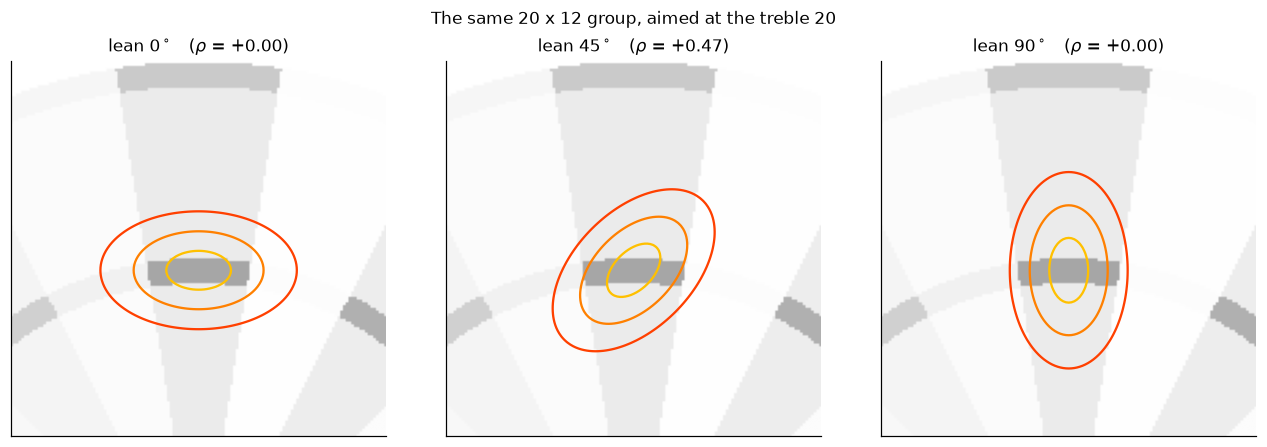

In [2]:
def cloud(S, ax, ay):
    inv = np.linalg.inv(S)
    dx, dy = X - ax, Y - ay
    q = inv[0, 0] * dx ** 2 + 2 * inv[0, 1] * dx * dy + inv[1, 1] * dy ** 2
    w = np.exp(-0.5 * q)
    return w / w.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, deg in zip(axes, (0, 45, 90)):
    S = rotated_sigma(MAJOR, MINOR, deg)
    w = cloud(S, 0.0, 103.0)                       # aimed at T20
    ax.imshow(BOARD, origin='lower', cmap='Greys', alpha=0.35,
              extent=[COORDS[0], COORDS[-1], COORDS[0], COORDS[-1]])
    ax.contour(X, Y, w, levels=4, cmap='autumn')
    ax.set_xlim(-60, 60); ax.set_ylim(50, 170)
    ax.set_title(f'lean {deg}$^\\circ$   ($\\rho$ = {correlation(S):+.2f})')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle('The same 20 x 12 group, aimed at the treble 20', y=1.0)
fig.tight_layout()

## 1. Does the lean change the board?

Notebook 12 found that a double bed is 8 mm deep and 52 mm long, so which of those two
dimensions your error runs into depends on where the bed sits. With a *leaning* group the
same argument applies, rotated: the easiest double should sit where the group's **minor**
axis points radially, which is perpendicular to the major axis.

In [3]:
def p_hit_double(number, Sigma, radius=166.0):
    lo, hi = C['SEGMENTS'][number][0]
    theta = (lo + hi) / 2 * np.pi
    w = cloud(Sigma, radius * np.cos(theta), radius * np.sin(theta))
    return float(w[(BOARD == 2 * number) & CHECKOUTS].sum()), np.degrees(theta) % 360

rows = []
for deg in (0, 30, 60, 90, 120, 150):
    S = rotated_sigma(MAJOR, MINOR, deg)
    res = [(p_hit_double(n, S)[0], p_hit_double(n, S)[1], n) for n in C['SEGMENTS']]
    best, worst = max(res), min(res)
    rows.append({'lean of the group': deg, 'best double': f'D{best[2]}',
                 'its angle': best[1], 'P(hit)': best[0],
                 'best angle - lean (mod 180)': (best[1] - deg) % 180,
                 'worst double': f'D{worst[2]}', 'worst P(hit)': worst[0]})
pd.DataFrame(rows).set_index('lean of the group').round(3)

,best double,its angle,P(hit),best angle - lean (mod 180),worst double,worst P(hit)
lean of the group,,,,,,
0,D20,90.0,0.209,90.0,D11,0.136
30,D12,126.0,0.208,96.0,D11,0.144
60,D15,324.0,0.209,84.0,D7,0.154
90,D6,0.0,0.209,90.0,D3,0.153
120,D4,36.0,0.208,96.0,D2,0.154
150,D18,54.0,0.209,84.0,D11,0.143


The rule is exact: **the easiest double sits perpendicular to the major axis of the group**.
The `best angle - lean` column holds at 90 degrees throughout, wandering only by the 6
degrees that the board's 18-degree segment spacing allows -- there is no double at exactly
the perpendicular, so the nearest one wins. The best double is worth 0.209 at every lean,
as it must be: the same ellipse, rotated, meeting the same bed at the same angle.

The reason is the one from notebook 12, rotated. A double bed is 8 mm deep and 52 mm long,
so you want your *precise* axis pointing across the 8 mm and your sloppy axis running along
the 52 mm. That happens where the minor axis is radial, which is perpendicular to the major.

So a leaning player has a different set of favourite doubles from an upright one, and they
rotate as the lean does.

### But does it change the *value*?

Easier doubles rotating around the board is not by itself a change in the game -- there are
twenty of them, and a player can simply use whichever suits. The board is close to
rotationally symmetric in its *geometry*, so the honest question is whether a leaning player
is actually worse off, or merely aiming somewhere else.

In [4]:
rows = []
for deg in (0, 18, 30, 45, 60, 75, 90):
    S = rotated_sigma(MAJOR, MINOR, deg)
    tr = transition_arrays(PX, 0.0, margin_mm=10.0, point_stride=STRIDE, Sigma_mm=S)
    m = ThreeDartMDP(tr['probs'], tr['checkout_probs'], tr['allowed_scores'], 501,
                     dart_cost=0.0, turn_cost=1.0).solve()
    rows.append({'lean': deg, 'rho': correlation(S),
                 'visits to finish 501': -m.V1[501]})
lean = pd.DataFrame(rows).set_index('lean')
print(f"spread across leans: {lean['visits to finish 501'].max() - lean['visits to finish 501'].min():.4f} visits")
print("for scale, notebook 12's round-vs-tall gap was 0.86 visits")
lean.round(4)

spread across leans: 0.6117 visits
for scale, notebook 12's round-vs-tall gap was 0.86 visits


,rho,visits to finish 501
lean,,
0,0.0000,10.2402
18,0.2991,10.2082
30,0.4193,10.1332
45,0.4706,9.9739
60,0.4193,9.8344
75,0.2577,9.7103
90,0.0000,9.6286


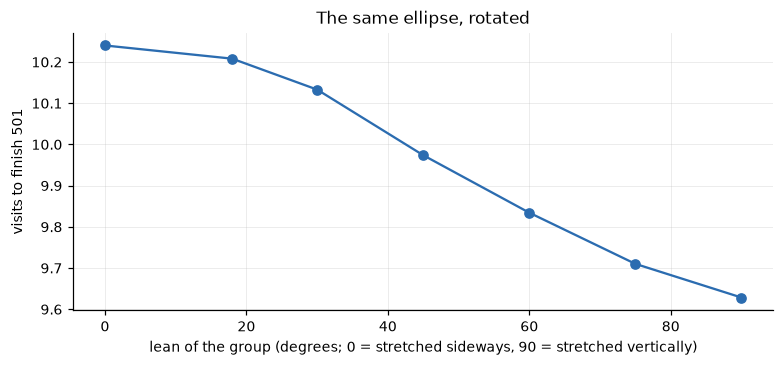

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.plot(lean.index, lean['visits to finish 501'], 'o-', color='#2b6cb0')
ax.set_xlabel('lean of the group (degrees; 0 = stretched sideways, 90 = stretched vertically)')
ax.set_ylabel('visits to finish 501')
ax.set_title('The same ellipse, rotated')
fig.tight_layout()

It changes the value, and by much more than the "just aim somewhere else" argument suggests:
**0.61 visits per leg** between the best and worst orientation of the *same ellipse*. For
scale, that is 71% of notebook 12's entire gap between a round player and a tall one -- and
here nothing about the group's size or shape has changed at all, only which way it leans.

The ordering is worth reading. Leaning **sideways** is the worst (10.24 visits) and leaning
**upright** the best (9.63), with the tilted cases in between and moving smoothly. So the
board is not indifferent to orientation the way a rotationally symmetric target would be.

I had expected this to be small, on the reasoning that the board has twenty segments and a
leaning player can simply pick one that suits them. That reasoning is wrong, and the next
section shows why: the board's *numbering* has an orientation even though its geometry very
nearly does not.

### Why the board cares which way you lean

The mechanism is worth pinning down, because it is a property of the *numbering* rather than
the geometry. Aim at the treble 20 and ask where the error goes.

In [6]:
rows = []
for deg, name in ((0, 'leaning sideways (major horizontal)'),
                  (90, 'leaning upright (major vertical)')):
    w = cloud(rotated_sigma(MAJOR, MINOR, deg), 0.0, 103.0)
    rows.append({'group': name,
                 'E[score]': float((w * BOARD).sum()),
                 'P(treble 20)': float(w[BOARD == 60].sum()),
                 'P(single 20)': float(w[BOARD == 20].sum()),
                 'P(the 1 / 5 neighbours)': float(w[(BOARD == 1) | (BOARD == 5)
                                                    | (BOARD == 3) | (BOARD == 15)].sum())})
pd.DataFrame(rows).set_index('group').round(3)

,E[score],P(treble 20),P(single 20),P(the 1 / 5 neighbours)
group,,,,
leaning sideways (major horizontal),19.784,0.151,0.433,0.405
leaning upright (major vertical),22.176,0.130,0.680,0.188


There it is. Both groups are the same size and shape; only the lean differs. Aiming at the
treble 20, the sideways-leaning player lands in the 1, 5, 3 or 15 **40.5%** of the time
against the upright player's 18.8%, and scores 19.8 per dart against 22.2.

The upright player actually hits *fewer* trebles (0.130 against 0.151). They score more
anyway, because their misses are cheap: a vertical error at the top of the board is radial,
so it drops them from the treble 20 into the *single* 20 -- still 20 points. The
sideways-leaning player's error is tangential, and takes them across a segment boundary into
the 1 or the 5.

That is the whole of it, and it is a fact about the numbering rather than the geometry. The
20 is flanked by 1 and 5 precisely so that sideways error is punished. A player whose error
happens to run radially at the top of the board is throwing into the direction the board
forgives; a player whose error runs tangentially is throwing into the direction it was
designed to punish.

## 3. What does ignoring the lean cost?

Take the 45 degree player, whose marginals are equal, and advise them with the best model
that cannot see a tilt: an axis-aligned one fitted to those marginals -- which is to say, a
*round* model. This is not a straw man; it is exactly what notebook 12's machinery would
infer about this player.

In [7]:
SX = SY = np.array([12.0, 16.5, 21.0])
RHO = np.array([-0.5, -0.25, 0.0, 0.25, 0.5])
SIGMAS, _ = sigma_matrices(SX, SY, RHO)
t0 = time.perf_counter()
rec = ShapeRecommender(SIGMAS, board_pixels=PX, point_stride=STRIDE)
print(f'{len(rec.models)} MDPs solved in {time.perf_counter()-t0:.0f}s '
      '(a tilt multiplies the solve grid; it is not free like a bias)')

TRUE = rotated_sigma(MAJOR, MINOR, 45.0)
MARGINAL = np.diag(np.diag(TRUE))            # what an axis-aligned fit would see
print(f'\ntrue    : major {MAJOR}, minor {MINOR}, lean 45deg, rho {correlation(TRUE):+.2f}')
print(f'marginal: sigma_x {np.sqrt(MARGINAL[0,0]):.2f}, sigma_y {np.sqrt(MARGINAL[1,1]):.2f}, '
      f'rho {correlation(MARGINAL):+.2f}  -- a round throw')

N_LEGS = 200
rows = []
for name, belief in [('knows the lean (oracle)', (TRUE, np.zeros(2))),
                     ('sees only the marginals (round)', (MARGINAL, np.zeros(2)))]:
    rng = np.random.default_rng(31)
    post = ParticleThrowPosterior(200, band='league', tilt=True, board=rec.board,
                                  checkouts=rec.checkouts, rng=np.random.default_rng(1))
    visits, lost = [], []
    for _ in range(N_LEGS):
        log = []
        play_leg(rec, post, TRUE, np.zeros(2), rng, policy=belief, record=log)
        df = pd.DataFrame(log)
        visits.append(int((df.state_dart == 1).sum()))
        lost.append(df.value_loss.sum())
    visits, lost = np.array(visits), np.array(lost)
    rows.append({'model believes': name, 'visits lost per leg': lost.mean(),
                 '+/-': lost.std(ddof=1) / np.sqrt(N_LEGS),
                 'realised visits per leg': visits.mean()})
pd.DataFrame(rows).set_index('model believes').round(3)

45 MDPs solved in 333s (a tilt multiplies the solve grid; it is not free like a bias)

true    : major 20.0, minor 12.0, lean 45deg, rho +0.47
marginal: sigma_x 16.49, sigma_y 16.49, rho +0.00  -- a round throw


,visits lost per leg,+/-,realised visits per leg
model believes,,,
knows the lean (oracle),0.000,0.000,10.31
sees only the marginals (round),0.147,0.006,10.24


**About 0.15 visits per leg**, which sits above notebook 12's cost for ignoring the
*shape* (0.11) and well below notebook 13's for ignoring a pull (0.89).

It is worth being clear how hard this test is on the axis-aligned model. At 45 degrees the
marginal spreads are exactly equal, so a model carrying only $\sigma_x$ and $\sigma_y$ does
not merely approximate this player -- it sees a **perfectly round throw**, with no hint that
anything is being missed. The fitted numbers would look clean and the diagnostics would look
fine. This is the largest error a lean can hide behind marginals, and it is worth about a
seventh of a visit a leg -- more, it turns out, than the shape the marginals *do* show.

(The realised-visits column runs the other way again, and by now the reason is familiar: it
carries roughly thirty times the standard error of the expected-loss measure and cannot
resolve a tenth of a visit over 200 legs. The loss column is the one to read.)

## 2. Can the lean be learned from scores?

The question I expected to sink this. A correlation is a second-order feature of the landing
cloud, and notebook 07 established that a score histogram cannot see *inside* an 8 mm bed --
so reading the orientation of an ellipse out of a bag of numbers sounded like asking too
much.

There is an exact answer available without simulating anything. Notebook 09's information
machinery already differentiates the score distribution with respect to the full covariance,
$\Sigma_{xx}$, $\Sigma_{xy}$ and $\Sigma_{yy}$, so the asymptotic standard error of $\rho$
follows by the delta method -- and, as in notebook 09, it depends enormously on where the
player is throwing.

In [8]:
from darts.design import (candidate_targets, c_criterion, information_at_points,
                          information_maps, sigma_gradient)

N_REF = 200

def polar(r, deg):
    return (int(round(CENTRE + r * np.cos(np.deg2rad(deg)) / MM)),
            int(round(CENTRE + r * np.sin(np.deg2rad(deg)) / MM)))

def se_of_rho(Sigma, n=N_REF):
    '''Asymptotic SE of rho, by the delta method on the (b, Sigma) information.'''
    sx, sy = np.sqrt(Sigma[0, 0]), np.sqrt(Sigma[1, 1])
    r = correlation(Sigma)
    c = np.array([0.0, 0.0, -r / (2 * sx ** 2), 1.0 / (sx * sy), -r / (2 * sy ** 2)])
    maps = information_maps(PX, Sigma, board=BOARD)
    targets = {'bull': polar(0, 0), 'T20': polar(103, 0),
               '20, outer single @134mm': polar(134, 0), 'D20': polar(166, 0)}
    out = {}
    for nm, pt in targets.items():
        I = maps['info'][pt[0], pt[1]]
        out[nm] = (float(np.sqrt(c_criterion(I, c) / n)),
                   float(np.sqrt(c_criterion(I, sigma_gradient(Sigma)) / n)))
    return out, maps, c

# the information depends on the true parameters, so evaluate it at the player
# this notebook actually follows, and at the upright one for contrast
PROTAGONIST = rotated_sigma(MAJOR, MINOR, 45.0)
UPRIGHT = rotated_sigma(MAJOR, MINOR, 90.0)
rows = []
for label, S in [('the 45 degree player', PROTAGONIST),
                 ('the upright player', UPRIGHT)]:
    res, _, _ = se_of_rho(S)
    for nm, (se_r, se_s) in res.items():
        rows.append({'player': label, 'target': nm,
                     'SE of rho (200 darts)': se_r,
                     'SE of sigma (200 darts)': se_s,
                     'darts to pin rho to +/-0.1': (se_r * np.sqrt(N_REF) / 0.1) ** 2})
fisher = pd.DataFrame(rows).set_index(['player', 'target'])
fisher.round(3)

SE of rho (200 darts)  \
player               target                                           
the 45 degree player bull                                     0.068   
                     T20                                      0.209   
                     20, outer single @134mm                  0.167   
                     D20                                      0.233   
the upright player   bull                                     0.088   
                     T20                                      0.412   
                     20, outer single @134mm                  0.259   
                     D20                                      0.419   

                                              SE of sigma (200 darts)  \
player               target                                             
the 45 degree player bull                                       1.036   
                     T20                                        1.211   
                     20, outer single @134mm                    0.824   
                     D20                                        1.506   
the upright player   bull                                       1.038   
                     T20                                        1.493   
                     20, outer single @134mm                    1.107   
                     D20                                        1.644   

                                              darts to pin rho to +/-0.1  
player               target                                               
the 45 degree player bull                                         93.313  
                     T20                                         875.491  
                     20, outer single @134mm                     556.447  
                     D20                                        1082.908  
the upright player   bull                                        154.576  
                     T20                                        3397.157  
                     20, outer single @134mm                    1344.871  
                     D20                                        3513.597

best target for the LEAN  :     BULL at r =   0.0 mm   SE(rho)   = 0.068
best target for the SPREAD:        5 at r = 133.7 mm   SE(sigma) = 0.814


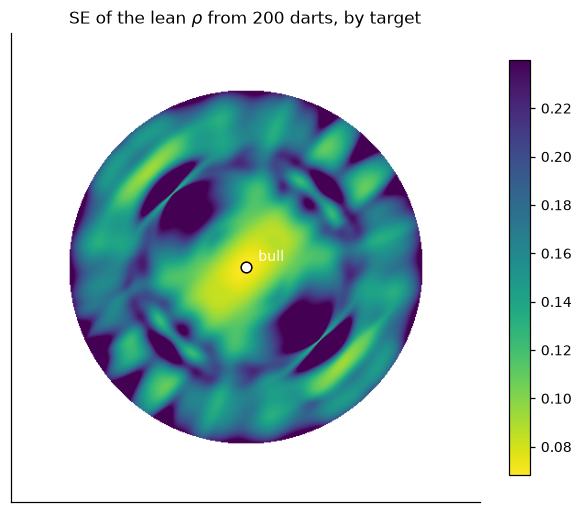

In [9]:
_, maps, c_rho = se_of_rho(PROTAGONIST)
cand = candidate_targets(PX, point_stride=STRIDE)
I_pts = information_at_points(maps, cand)
v_rho = c_criterion(I_pts, c_rho)
v_sig = c_criterion(I_pts, sigma_gradient(PROTAGONIST))
j_rho, j_sig = int(np.argmin(v_rho)), int(np.argmin(v_sig))

def radius(pt):
    return float(np.hypot(*((np.asarray(pt) - CENTRE) * MM)))

print(f'best target for the LEAN  : {aim_description(cand[j_rho], PX):>8s} '
      f'at r = {radius(cand[j_rho]):5.1f} mm   SE(rho)   = {np.sqrt(v_rho[j_rho]/N_REF):.3f}')
print(f'best target for the SPREAD: {aim_description(cand[j_sig], PX):>8s} '
      f'at r = {radius(cand[j_sig]):5.1f} mm   SE(sigma) = {np.sqrt(v_sig[j_sig]/N_REF):.3f}')

se_rho_map = np.full((PX, PX), np.nan)
rad = np.hypot(*np.meshgrid(np.arange(PX) - CENTRE, np.arange(PX) - CENTRE, indexing='ij'))
inside = rad <= 170 / MM
se_rho_map[inside] = np.sqrt(c_criterion(maps['info'][inside], c_rho) / N_REF)

fig, ax = plt.subplots(figsize=(5.6, 5.0))
im = ax.imshow(se_rho_map, origin='lower', cmap='viridis_r',
               vmax=np.nanpercentile(se_rho_map, 90))
ax.plot(CENTRE, CENTRE, 'o', ms=7, color='white', mec='black')
ax.annotate('bull', (CENTRE, CENTRE), textcoords='offset points', xytext=(8, 4),
            color='white', fontsize=9)
ax.set_title(f'SE of the lean $\\rho$ from {N_REF} darts, by target')
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()

I was wrong, and pleasingly so: the lean is the **easiest** of the three to measure, not the
hardest.

For the 45 degree player, 200 darts at the bull pin $\rho$ to $\pm 0.068$ -- roughly 93
darts for a precision of $\pm 0.1$. The same 200 darts measure that player's *spread* only to
$\pm 1.04$ mm, which is about 6% of it. The lean is the better-determined quantity.

And the best place to measure it is **the bull**, which is a different target from the best
place to measure the spread (the outer single at about 134 mm). That falls out of the board's
structure once stated: the twenty segment boundaries all meet at the centre, so the bull is
where *angular* information is finest. A leaning group spills preferentially along one
diagonal, and the tally of which numbers you hit reads the orientation off directly. Rings
carry radial information and tell you the size; segments carry angular information and tell
you the lean. Two orthogonal questions, two different targets.

The contrast with T20 is the familiar one: 0.209 against 0.068 for the same player, so about
nine times the darts for the same answer. T20 continues to be the worst place to learn
anything about anybody.

In [10]:
# The Fisher numbers describe the variance of an unbiased estimator. At a few
# hundred darts the posterior is still pulled toward its prior, so compare the
# whole error and not just the spread -- and over several runs, since one run
# of a stochastic filter says very little.
TRUTH_RHO = correlation(PROTAGONIST)
L = np.linalg.cholesky(PROTAGONIST)
N_DARTS, N_SEEDS = 600, 12

def drill_rho(target, seed):
    pf = ParticleThrowPosterior(600, band='league', tilt=True, board=BOARD,
                                checkouts=CHECKOUTS,
                                rng=np.random.default_rng(1000 + seed))
    rng = np.random.default_rng(seed)
    for _ in range(N_DARTS):
        land = target + L @ rng.standard_normal(2)
        col = int(round(land[0] / MM)) + CENTRE
        row = int(round(land[1] / MM)) + CENTRE
        v = int(BOARD[row, col]) if 0 <= row < PX and 0 <= col < PX else 0
        pf.update(target, v, pixel=False)
    return pf.mean_rho()

rows = []
for name, target in [('bull', np.array([0.0, 0.0])), ('T20', np.array([0.0, 103.0]))]:
    est = np.array([drill_rho(target, s) for s in range(N_SEEDS)])
    se_pred = fisher.loc[('the 45 degree player', name), 'SE of rho (200 darts)']
    rows.append({'drill target': name, 'mean fitted rho': est.mean(),
                 'bias': est.mean() - TRUTH_RHO, 'sd across runs': est.std(ddof=1),
                 'rmse': np.sqrt(((est - TRUTH_RHO) ** 2).mean()),
                 'Fisher SE at 600 darts': se_pred * np.sqrt(N_REF / N_DARTS)})
print(f'true rho = {TRUTH_RHO:.3f}, {N_SEEDS} runs of {N_DARTS} darts each')
pd.DataFrame(rows).set_index('drill target').round(3)

true rho = 0.471, 12 runs of 600 darts each


,mean fitted rho,bias,sd across runs,rmse,Fisher SE at 600 darts
drill target,,,,,
bull,0.432,-0.039,0.066,0.074,0.039
T20,0.341,-0.130,0.097,0.160,0.121


The direction survives contact with the actual estimator, and the size does not.

Over twelve runs of 600 darts, the bull gives an RMSE of 0.074 against T20's 0.160 -- the
bull is better by a factor of 2.2, where the Fisher numbers promised about three. The gap
between the two is itself the interesting part, and it is visible in the decomposition: T20's
error is mostly **bias** (-0.130) rather than spread (sd 0.097), while the bull's is smaller
in both parts (-0.039 and 0.066).

That is prior shrinkage doing exactly what it should. The prior puts $\rho$ near zero; the
truth is 0.47. A target that carries little information leaves the posterior close to that
prior, so it comes out *precise and wrong* -- low variance, large bias, and a standard error
that flatters it. Fisher information describes the variance of an unbiased estimator and is
blind to this, which is why the asymptotic ratio overstates the practical one.

Both targets underestimate the lean at 600 darts, though the bull only slightly -- 0.432
against a truth of 0.471. The honest summary is that a few hundred darts at the bull
establish both **that** a player leans and roughly how much, while the same darts at T20
establish only the first.

## Verdict

**The lean matters, it is learnable, and it was the parameter I most misjudged going in.**

1. *Does it change the board?* **Yes, by 0.61 visits per leg** between the worst and best
   orientation of an identical ellipse -- 71% of the round-versus-tall gap, from a group
   whose size and shape never change. Leaning upright beats leaning sideways, because the 20
   is flanked by the 1 and the 5 and the board punishes tangential error at the top. The
   favourite doubles rotate with the lean, sitting perpendicular to the major axis.
2. *Can it be learned from scores?* **Yes, more easily than the spread.** About 93 darts at
   the bull pin $\rho$ to $\pm 0.1$. The bull is the right target because every segment
   boundary meets there, and angular structure is what reveals an orientation -- a different
   target from the one that best measures size.
3. *What does ignoring it cost?* **About 0.15 visits per leg**, measured in the least
   forgiving case available: a 45 degree lean whose equal marginals make it look perfectly
   round to any axis-aligned model.

Two things I had wrong at the start, both corrected by measurement rather than argument.
I expected the lean to be nearly free because the board is almost rotationally symmetric --
it is, geometrically, and its *numbering* is not, which is where the 0.61 visits come from.
And I expected a correlation to be the hardest thing to read out of a score histogram, when
in fact it is the easiest, because scores are fundamentally a statement about *which segment*
a dart landed in and that is angular information.

### What this leaves

* **A tilt is not free to compute.** Bias is cheap because it leaves the board alone; a lean
  changes $\Sigma$, so it multiplies the MDP solve grid exactly as anisotropy does -- 45
  solves and five and a half minutes here, against 25 for the untilted grid. The particle filter makes
  the *belief* side free, and does nothing for the solve side.
* **The prior on $\rho$ is doing real work** at these sample sizes, and it is currently a
  guess: centred on no lean with a standard deviation of 0.3. What real players' leans
  actually look like would change the shrinkage, and nobody has measured it.
* **The measurement design has not been redone for the lean.** Notebook 09 searched for the
  targets that best measure $\sigma$; the same machinery applied to $\rho$ found the bull by
  hand here, but the proper c-optimal and multi-target versions of that question are
  untouched -- and since the best targets for size and lean differ, a session measuring both
  wants a genuinely split design.